# Résumé RDF basé sur des sous-graphes orientés requêtes
## Implémentation — Dataset SWDF (Semantic Web Dog Food)

**Approche proposée (Section 7 du rapport)**  
L'unité naturelle d'usage d'un graphe RDF n'est pas le nœud isolé, mais le **sous-graphe correspondant aux motifs de requêtes (BGP)**.

### Pipeline :
1. Extraction des **BGP** depuis les requêtes SPARQL  
2. Construction des **sous-graphes** $S_q$  
3. Calcul du **score d'importance** $I(S) = \alpha \cdot \text{freq}(S) + \beta \cdot \text{EC}(S) + \gamma \cdot \text{Div}(S)$  
4. Sélection des **top-k** sous-graphes  
5. Connexion via **approximation du Steiner Tree**  
6. Évaluation par la métrique **Coverage**

## 1. Dataset — SWDF (Semantic Web Dog Food)

- **Schéma** : Ontologie SWC (Semantic Web Conference) — source : [lov.linkeddata.es](https://lov.linkeddata.es/dataset/lov/vocabs/swc)
- **Logs** : Requêtes SPARQL réelles extraites du serveur `data.semanticweb.org` — source : [LSQ / GitHub AKSW](https://github.com/AKSW/LSQ)
- **Période** : Mai 2014

In [1]:
import sys, os

# Forcer le répertoire de travail vers la racine du projet
PROJECT_ROOT = '/Users/a-m-s-c/websemantique'
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import networkx as nx
import numpy as np

from src.schema_graph import RDFSchemaGraph
from src.query_parser import SPARQLQueryParser, load_queries
from src.subgraph_builder import SubgraphBuilder
from src.importance import compute_frequency, compute_external_connectivity, compute_diversity, compute_importance_scores, print_scores
from src.summarizer import RDFSummarizer, select_top_k, connect_subgraphs
from src.evaluator import compute_coverage, compute_compactness, print_evaluation

SCHEMA_PATH  = "data/swdf_schema.ttl"
QUERIES_PATH = "data/swdf_queries.txt"

os.makedirs("output", exist_ok=True)
print(f"Répertoire de travail : {os.getcwd()}")
print("Imports OK ✓")

Répertoire de travail : /Users/a-m-s-c/websemantique
Imports OK ✓


## 2. Chargement et exploration du schéma RDF

In [2]:
schema = RDFSchemaGraph(SCHEMA_PATH, fmt="turtle")

classes = schema.classes()
properties = schema.properties()

print(f"=== Schéma SWDF (SWC Ontology) ===")
print(f"Nombre de classes    : {len(classes)}")
print(f"Nombre de propriétés : {len(properties)}")
print()
print("Classes :")
for c in sorted(classes):
    print(f"  - {c.split('#')[-1].split('/')[-1]}")
print()
print("Propriétés :")
for p in sorted(properties):
    print(f"  - {p.split('#')[-1].split('/')[-1]}")

=== Schéma SWDF (SWC Ontology) ===
Nombre de classes    : 18
Nombre de propriétés : 13

Classes :
  - AcademicEvent
  - Call
  - Chair
  - ConferenceEvent
  - Delegate
  - PanelEvent
  - Paper
  - Poster
  - Presenter
  - Proceedings
  - Programme
  - Role
  - SessionEvent
  - TalkEvent
  - TutorialEvent
  - WorkshopEvent
  - Organization
  - Person

Propriétés :
  - attendeeAt
  - hasAttendee
  - hasCall
  - hasProgramme
  - hasRelatedDocument
  - hasRole
  - heldBy
  - holdsRole
  - isProvidedBy
  - isSubEventOf
  - isSuperEventOf
  - proceedings
  - relatedToEvent


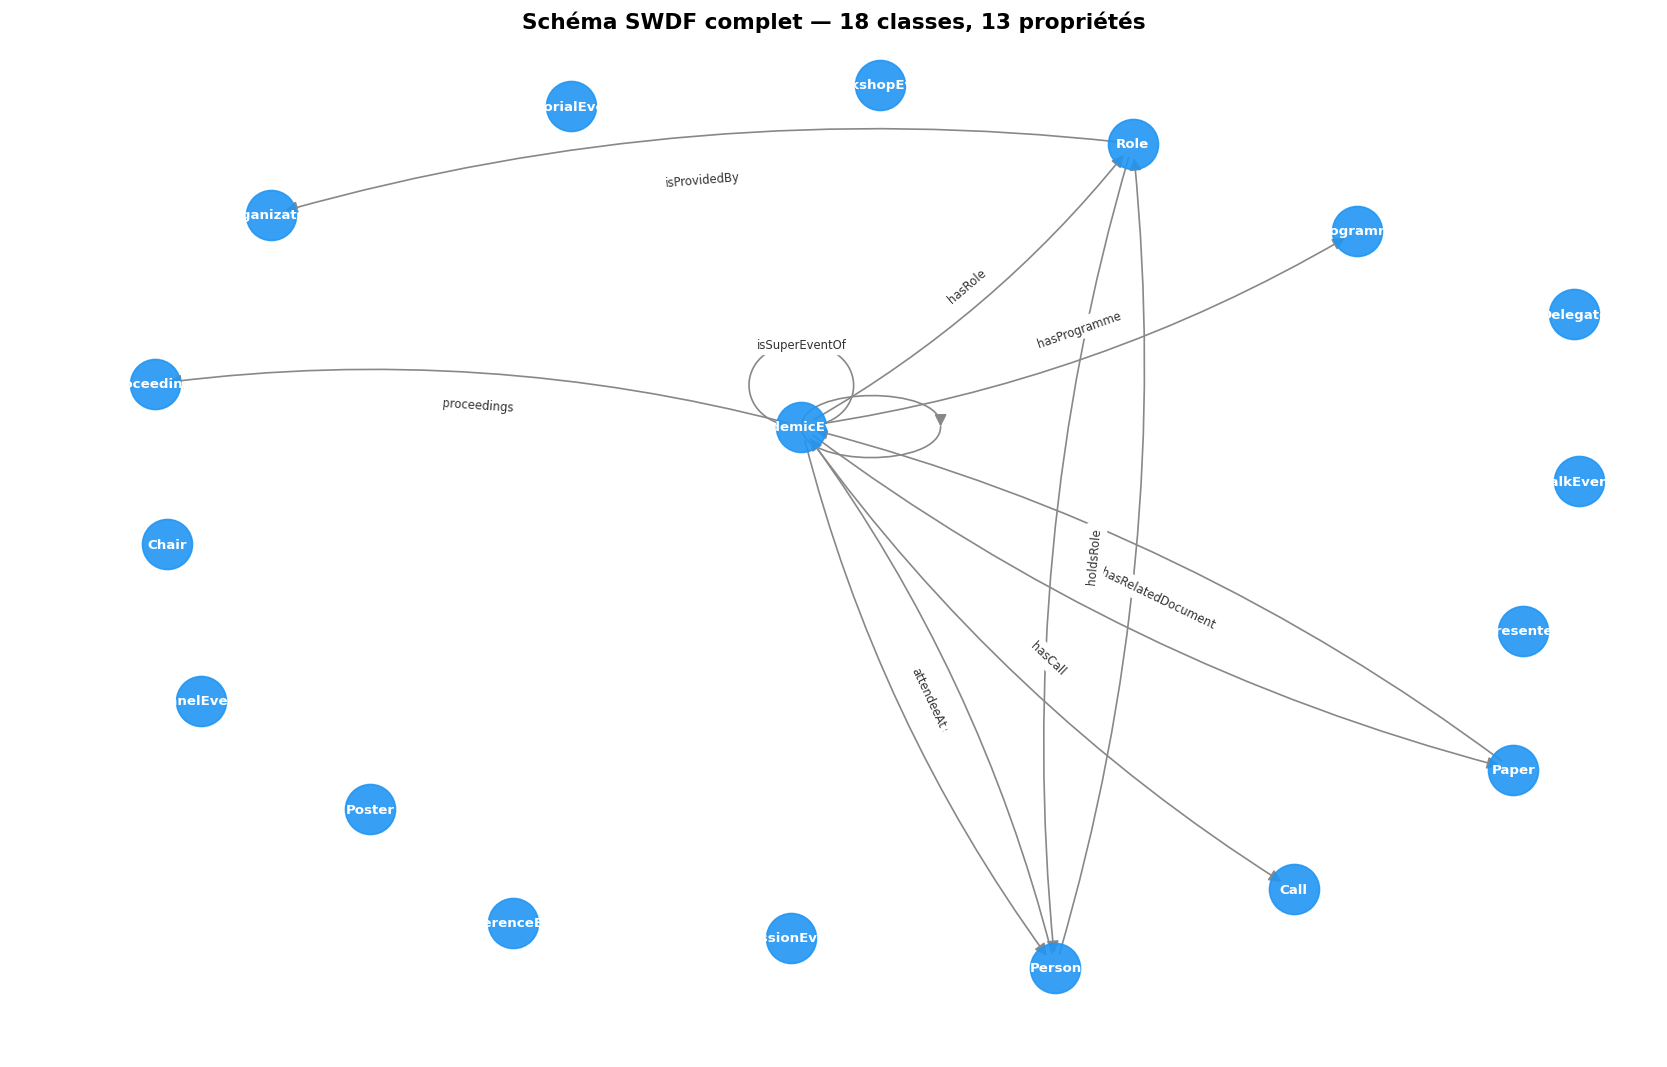

Schéma affiché


In [3]:
# Visualisation du schéma complet
fig, ax = plt.subplots(figsize=(14, 9))
G = schema.schema
pos = nx.spring_layout(G, seed=42, k=3.0)
labels = {n: n.split('#')[-1].split('/')[-1] for n in G.nodes()}

nx.draw_networkx_nodes(G, pos, node_color="#2196F3", node_size=900, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_color="white", font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, edge_color="#888", arrows=True, arrowsize=15,
                       connectionstyle="arc3,rad=0.1", ax=ax)
edge_labels = {(u,v): d['property'].split('#')[-1] for u,v,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7, font_color="#333", ax=ax)
ax.set_title(f"Schéma SWDF complet — {len(classes)} classes, {len(properties)} propriétés",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig("output/schema_complet.png", dpi=150, bbox_inches='tight')
plt.show()
print("Schéma affiché")

## 3. Chargement et parsing des requêtes SPARQL

In [4]:
queries = load_queries(QUERIES_PATH)
parser  = SPARQLQueryParser(schema)

print(f"Nombre de requêtes chargées : {len(queries)}")
print()

bgps = []
for i, q in enumerate(queries, 1):
    classes_q, props_q = parser.extract_bgp(q)
    bgps.append((classes_q, props_q))
    cls_short  = [c.split('#')[-1].split('/')[-1] for c in sorted(classes_q)]
    prop_short = [p.split('#')[-1].split('/')[-1] for p in sorted(props_q)]
    print(f"Q{i:02d} | Classes : {cls_short}")
    print(f"     | Propriétés : {prop_short}")
    print()

Nombre de requêtes chargées : 15

Q01 | Classes : ['ConferenceEvent']
     | Propriétés : ['hasAcronym', 'label']

Q02 | Classes : ['WorkshopEvent']
     | Propriétés : ['hasAcronym', 'label']

Q03 | Classes : []
     | Propriétés : ['completeGraph', 'hasAcronym']

Q04 | Classes : ['AcademicEvent', 'ConferenceEvent', 'Paper']
     | Propriétés : ['relatedToEvent']

Q05 | Classes : ['AcademicEvent', 'Presenter', 'Role', 'TalkEvent', 'Person']
     | Propriétés : ['hasRole', 'holdsRole']

Q06 | Classes : ['AcademicEvent', 'ConferenceEvent', 'Paper', 'TalkEvent']
     | Propriétés : ['isSubEventOf', 'relatedToEvent']

Q07 | Classes : ['AcademicEvent', 'ConferenceEvent', 'Person']
     | Propriétés : ['attendeeAt']

Q08 | Classes : ['AcademicEvent', 'SessionEvent', 'TalkEvent']
     | Propriétés : ['isSubEventOf']

Q09 | Classes : ['AcademicEvent', 'ConferenceEvent', 'Presenter', 'Role', 'TalkEvent', 'Person']
     | Propriétés : ['hasRole', 'heldBy', 'isSubEventOf']

Q10 | Classes : ['Aca

## 4. Construction des sous-graphes $S_q$

Pour chaque requête $q$, on construit le sous-graphe du schéma induit par les classes et propriétés de son BGP.

In [5]:
builder    = SubgraphBuilder(schema)
subgraphs  = builder.build_all(bgps)

print(f"Motifs distincts identifiés : {len(subgraphs)}")
print()
print(f"{'#':<4} {'Freq':>5}  {'Nœuds':>6}  {'Arêtes':>6}  Classes")
print("-" * 70)
for i, sq in enumerate(subgraphs, 1):
    cls = [c.split('#')[-1].split('/')[-1] for c in sorted(sq.classes)]
    print(f"{i:<4} {sq.freq:>5}  {sq.graph.number_of_nodes():>6}  {sq.graph.number_of_edges():>6}  {cls}")

Motifs distincts identifiés : 14

#     Freq   Nœuds  Arêtes  Classes
----------------------------------------------------------------------
1        1       1       0  ['ConferenceEvent']
2        1       1       0  ['WorkshopEvent']
3        1       3       1  ['AcademicEvent', 'ConferenceEvent', 'Paper']
4        1       5       2  ['AcademicEvent', 'Presenter', 'Role', 'TalkEvent', 'Person']
5        1       4       2  ['AcademicEvent', 'ConferenceEvent', 'Paper', 'TalkEvent']
6        1       3       1  ['AcademicEvent', 'ConferenceEvent', 'Person']
7        1       3       1  ['AcademicEvent', 'SessionEvent', 'TalkEvent']
8        1       6       3  ['AcademicEvent', 'ConferenceEvent', 'Presenter', 'Role', 'TalkEvent', 'Person']
9        1       3       1  ['AcademicEvent', 'Paper', 'WorkshopEvent']
10       1       2       1  ['AcademicEvent', 'Programme']
11       1       4       2  ['AcademicEvent', 'Call', 'ConferenceEvent', 'Paper']
12       1       3       1  ['AcademicEven

## 5. Calcul des scores d'importance $I(S)$

$$I(S) = \alpha \cdot \text{freq}(S) + \beta \cdot \text{ExternalConnectivity}(S) + \gamma \cdot \text{Diversité}(S)$$

Avec $\alpha + \beta + \gamma = 1$ et normalisation min-max de chaque composante.

In [6]:
ALPHA, BETA, GAMMA = 0.5, 0.3, 0.2
total_queries = len(queries)

ranked = compute_importance_scores(subgraphs, schema, total_queries,
                                   alpha=ALPHA, beta=BETA, gamma=GAMMA)

print(f"Paramètres : α={ALPHA}, β={BETA}, γ={GAMMA}")
print()
print(f"{'Rang':<5} {'Score':>8}  {'Freq':>5}  {'EC':>4}  {'Div':>5}  Motif")
print("=" * 75)
for rank, (sq, score) in enumerate(ranked, 1):
    freq_v = compute_frequency(sq, total_queries)
    ec_v   = compute_external_connectivity(sq, schema)
    div_v  = compute_diversity(sq)
    cls    = [c.split('#')[-1].split('/')[-1] for c in sorted(sq.classes)]
    print(f"{rank:<5} {score:>8.4f}  {freq_v:>5.2f}  {ec_v:>4}  {div_v:>5.2f}  {cls}")

Paramètres : α=0.5, β=0.3, γ=0.2

Rang     Score   Freq    EC    Div  Motif
1       0.4179   0.07     8   1.00  ['AcademicEvent', 'ConferenceEvent', 'Person']
2       0.4179   0.07     8   1.00  ['AcademicEvent', 'SessionEvent', 'TalkEvent']
3       0.4179   0.07     8   1.00  ['AcademicEvent', 'ConferenceEvent', 'PanelEvent']
4       0.4179   0.07     8   1.00  ['AcademicEvent', 'ConferenceEvent', 'TalkEvent']
5       0.3949   0.07     7   1.00  ['AcademicEvent', 'Programme']
6       0.3718   0.07     6   1.00  ['AcademicEvent', 'ConferenceEvent', 'Paper']
7       0.3718   0.07     6   1.00  ['AcademicEvent', 'Presenter', 'Role', 'TalkEvent', 'Person']
8       0.3718   0.07     6   1.00  ['AcademicEvent', 'ConferenceEvent', 'Paper', 'TalkEvent']
9       0.3718   0.07     6   1.00  ['AcademicEvent', 'ConferenceEvent', 'Presenter', 'Role', 'TalkEvent', 'Person']
10      0.3718   0.07     6   1.00  ['AcademicEvent', 'Paper', 'WorkshopEvent']
11      0.3718   0.07     6   1.00  ['Academic

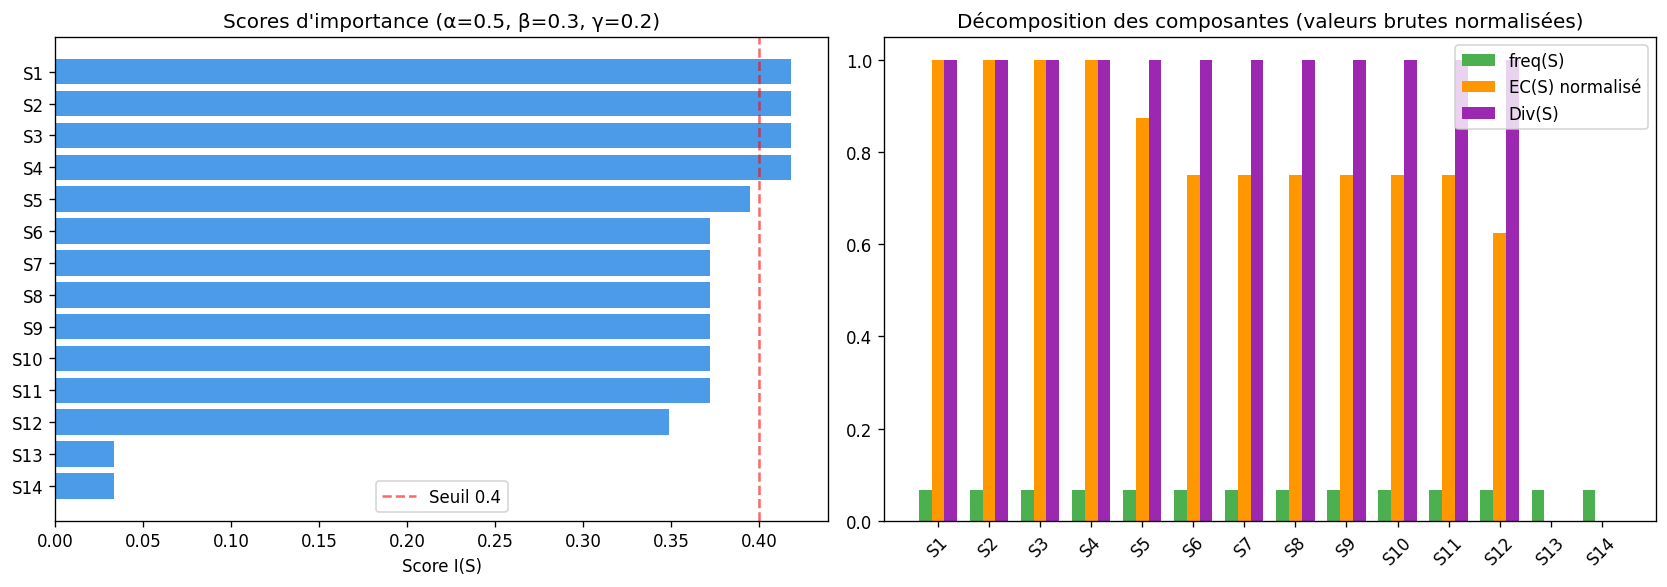

In [7]:
# Graphique des scores d'importance
scores_vals = [s for _, s in ranked]
labels_bar  = [f"S{i+1}" for i in range(len(ranked))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scores globaux
axes[0].barh(labels_bar[::-1], scores_vals[::-1], color="#4C9BE8")
axes[0].set_xlabel("Score I(S)")
axes[0].set_title(f"Scores d'importance (α={ALPHA}, β={BETA}, γ={GAMMA})")
axes[0].axvline(x=0.4, color='red', linestyle='--', alpha=0.6, label='Seuil 0.4')
axes[0].legend()

# Décomposition freq / EC / Div
freqs_v = [compute_frequency(sq, total_queries) for sq, _ in ranked]
ecs_v   = [compute_external_connectivity(sq, schema) for sq, _ in ranked]
divs_v  = [compute_diversity(sq) for sq, _ in ranked]

x = np.arange(len(ranked))
w = 0.25
axes[1].bar(x - w, freqs_v, w, label='freq(S)', color='#4CAF50')
axes[1].bar(x,     [e/max(ecs_v+[1]) for e in ecs_v], w, label='EC(S) normalisé', color='#FF9800')
axes[1].bar(x + w, divs_v, w, label='Div(S)', color='#9C27B0')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_bar, rotation=45)
axes[1].set_title("Décomposition des composantes (valeurs brutes normalisées)")
axes[1].legend()

plt.tight_layout()
os.makedirs("output", exist_ok=True)
plt.savefig("output/scores_importance.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Sélection top-k et construction du résumé (Steiner Tree)

In [8]:
K = 5
selected = select_top_k(ranked, K)
summary  = connect_subgraphs(selected, schema)

print(f"Top-k sélectionnés : k = {K}")
print()
for i, sq in enumerate(selected, 1):
    cls  = [c.split('#')[-1].split('/')[-1] for c in sorted(sq.classes)]
    prop = [p.split('#')[-1].split('/')[-1] for p in sorted(sq.properties)]
    print(f"  S{i} | fréq={sq.freq} | classes={cls} | propriétés={prop}")

print()
print(f"Résumé final : {summary.number_of_nodes()} nœuds, {summary.number_of_edges()} arêtes")

Top-k sélectionnés : k = 5

  S1 | fréq=1 | classes=['AcademicEvent', 'ConferenceEvent', 'Person'] | propriétés=['attendeeAt']
  S2 | fréq=1 | classes=['AcademicEvent', 'SessionEvent', 'TalkEvent'] | propriétés=['isSubEventOf']
  S3 | fréq=1 | classes=['AcademicEvent', 'ConferenceEvent', 'PanelEvent'] | propriétés=['isSubEventOf']
  S4 | fréq=1 | classes=['AcademicEvent', 'ConferenceEvent', 'TalkEvent'] | propriétés=['isSubEventOf']
  S5 | fréq=1 | classes=['AcademicEvent', 'Programme'] | propriétés=['hasProgramme']

Résumé final : 7 nœuds, 5 arêtes


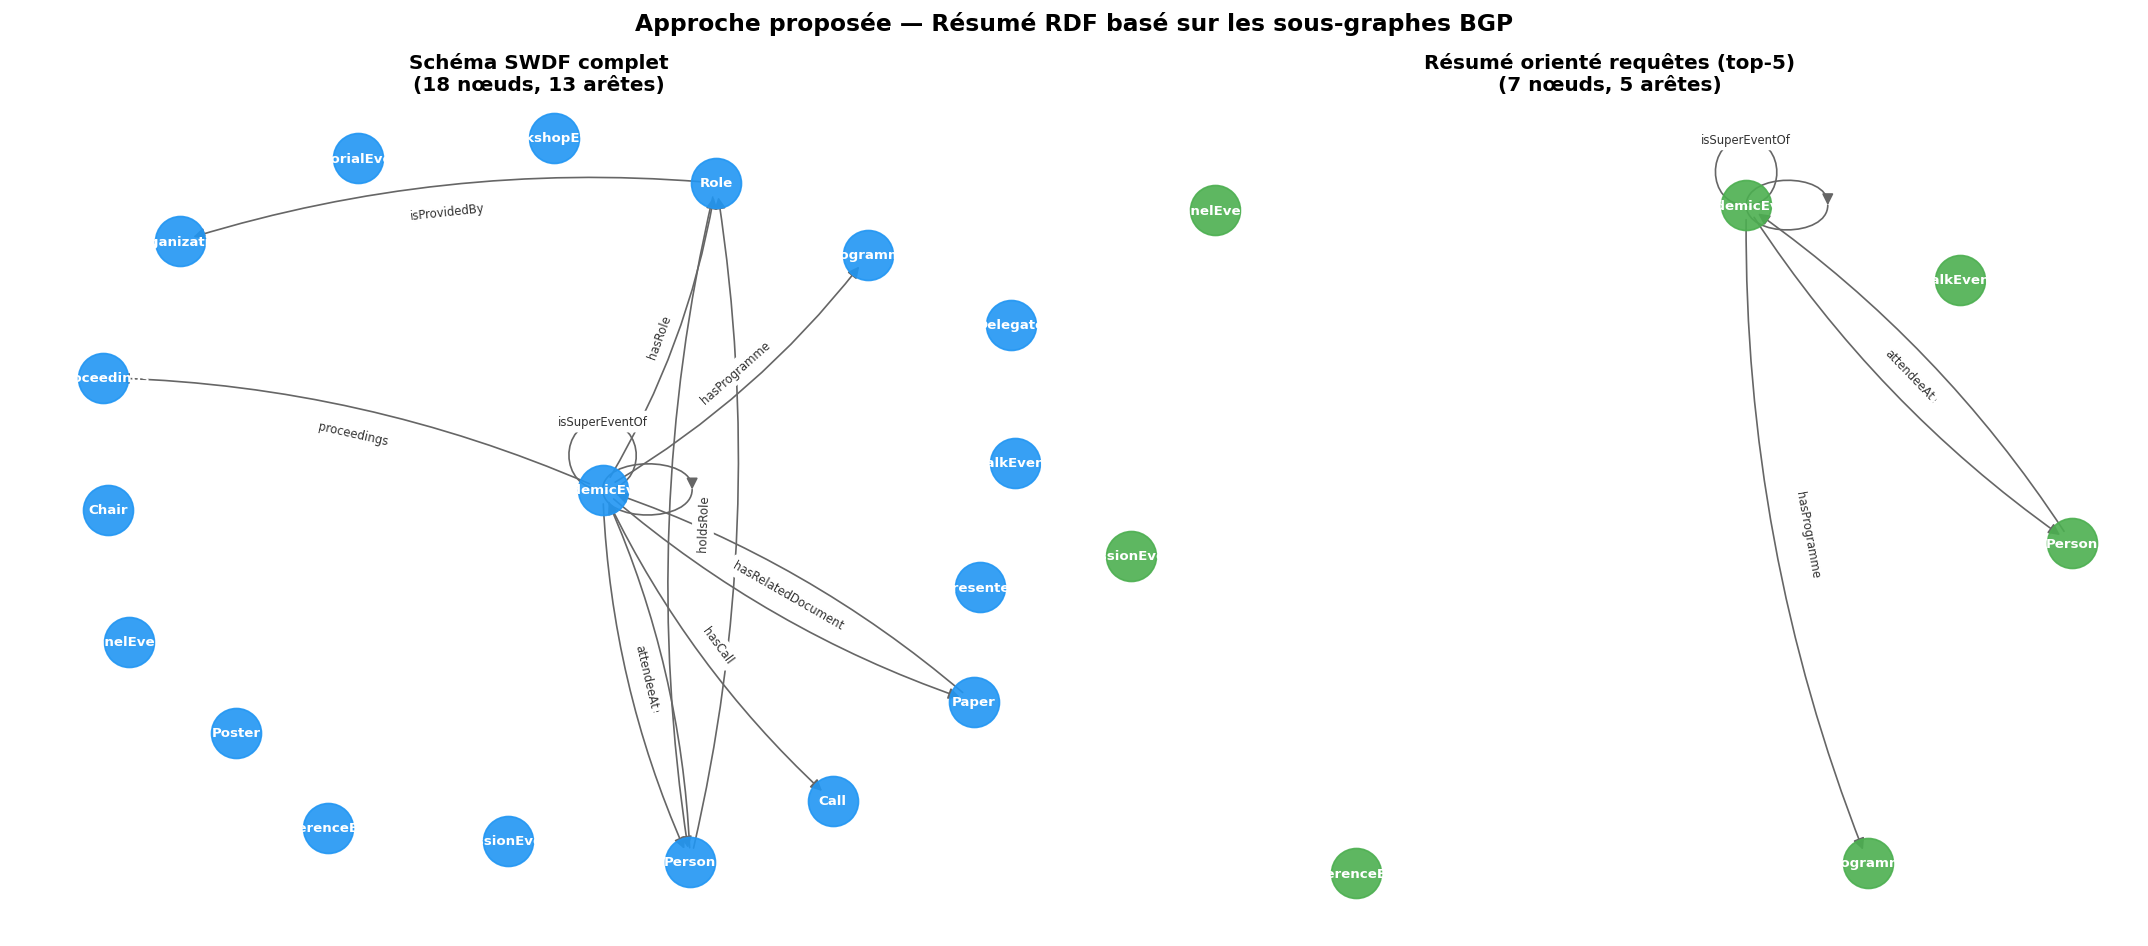

In [9]:
# Visualisation côte à côte : Schéma complet vs Résumé
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

def draw_rdf(G, ax, title, node_color):
    if G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, "Vide", ha='center', va='center')
        return
    pos = nx.spring_layout(G, seed=42, k=2.5)
    lbl = {n: n.split('#')[-1].split('/')[-1] for n in G.nodes()}
    nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=900, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, lbl, font_size=8, font_color='white', font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color='#666', arrows=True, arrowsize=14,
                           connectionstyle='arc3,rad=0.1', ax=ax)
    elabels = {(u,v): d.get('property','').split('#')[-1] for u,v,d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, elabels, font_size=7, font_color='#333', ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

draw_rdf(schema.schema, axes[0],
         f"Schéma SWDF complet\n({schema.schema.number_of_nodes()} nœuds, {schema.schema.number_of_edges()} arêtes)",
         "#2196F3")
draw_rdf(summary, axes[1],
         f"Résumé orienté requêtes (top-{K})\n({summary.number_of_nodes()} nœuds, {summary.number_of_edges()} arêtes)",
         "#4CAF50")

plt.suptitle("Approche proposée — Résumé RDF basé sur les sous-graphes BGP", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("output/schema_vs_resume.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Évaluation — Métrique de Coverage

$$\text{Coverage} = \frac{\text{éléments couverts par le résumé}}{\text{éléments apparaissant dans les requêtes}}$$

In [10]:
metrics     = compute_coverage(summary, subgraphs)
compactness = compute_compactness(summary, schema)
print_evaluation(metrics, compactness)


ÉVALUATION DU RÉSUMÉ
Coverage nœuds  : 58.33% (7/12)
Coverage arêtes : 37.50% (3/8)
Coverage globale: 50.00%
Compacité       : 61.29%

Classes manquantes :
  - Call
  - Paper
  - Presenter
  - Role
  - WorkshopEvent

Relations manquantes :
  - AcademicEvent --[hasCall]--> Call
  - AcademicEvent --[hasRole]--> Role
  - Paper --[relatedToEvent]--> AcademicEvent
  - Role --[heldBy]--> Person
  - Person --[holdsRole]--> Role


## 8. Analyse — Impact du paramètre k (Coverage vs Compacité)

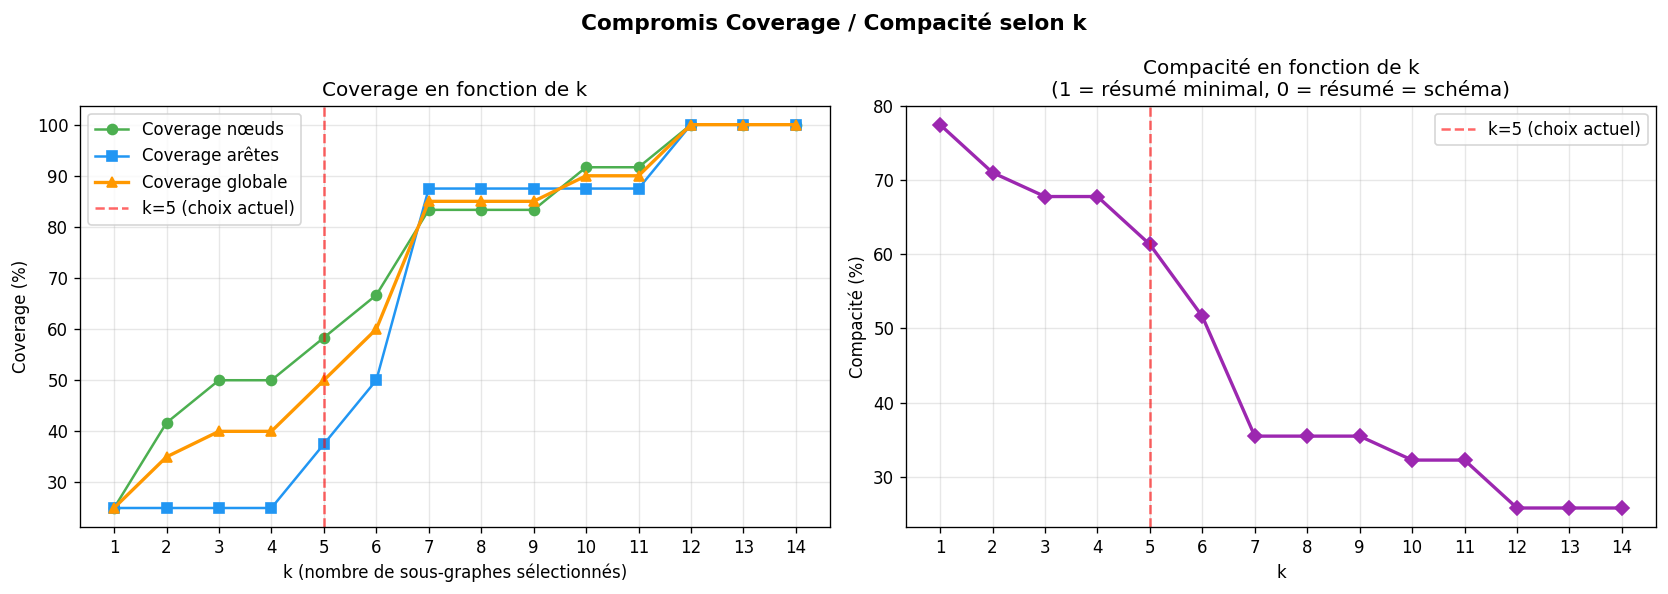


  k    Cov. nœuds   Cov. arêtes   Cov. globale   Compacité
----------------------------------------------------------
  1         25.0%         25.0%          25.0%       77.4%
  2         41.7%         25.0%          35.0%       71.0%
  3         50.0%         25.0%          40.0%       67.7%
  4         50.0%         25.0%          40.0%       67.7%
  5         58.3%         37.5%          50.0%       61.3%
  6         66.7%         50.0%          60.0%       51.6%
  7         83.3%         87.5%          85.0%       35.5%
  8         83.3%         87.5%          85.0%       35.5%
  9         83.3%         87.5%          85.0%       35.5%
 10         91.7%         87.5%          90.0%       32.3%
 11         91.7%         87.5%          90.0%       32.3%
 12        100.0%        100.0%         100.0%       25.8%
 13        100.0%        100.0%         100.0%       25.8%
 14        100.0%        100.0%         100.0%       25.8%


In [11]:
k_values     = list(range(1, len(subgraphs) + 1))
coverages_n  = []
coverages_e  = []
coverages_g  = []
compactnesses = []

for k in k_values:
    sel  = select_top_k(ranked, k)
    summ = connect_subgraphs(sel, schema)
    m    = compute_coverage(summ, subgraphs)
    c    = compute_compactness(summ, schema)
    coverages_n.append(m['coverage_nodes'])
    coverages_e.append(m['coverage_edges'])
    coverages_g.append(m['coverage_global'])
    compactnesses.append(c)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, [v*100 for v in coverages_n], 'o-', color='#4CAF50', label='Coverage nœuds')
axes[0].plot(k_values, [v*100 for v in coverages_e], 's-', color='#2196F3', label='Coverage arêtes')
axes[0].plot(k_values, [v*100 for v in coverages_g], '^-', color='#FF9800', label='Coverage globale', linewidth=2)
axes[0].axvline(x=K, color='red', linestyle='--', alpha=0.6, label=f'k={K} (choix actuel)')
axes[0].set_xlabel('k (nombre de sous-graphes sélectionnés)')
axes[0].set_ylabel('Coverage (%)')
axes[0].set_title('Coverage en fonction de k')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_values)

axes[1].plot(k_values, [v*100 for v in compactnesses], 'D-', color='#9C27B0', linewidth=2)
axes[1].axvline(x=K, color='red', linestyle='--', alpha=0.6, label=f'k={K} (choix actuel)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Compacité (%)')
axes[1].set_title('Compacité en fonction de k\n(1 = résumé minimal, 0 = résumé = schéma)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_values)

plt.suptitle("Compromis Coverage / Compacité selon k", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("output/coverage_vs_k.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'k':>3}  {'Cov. nœuds':>12}  {'Cov. arêtes':>12}  {'Cov. globale':>13}  {'Compacité':>10}")
print("-" * 58)
for k, cn, ce, cg, comp in zip(k_values, coverages_n, coverages_e, coverages_g, compactnesses):
    print(f"{k:>3}  {cn*100:>11.1f}%  {ce*100:>11.1f}%  {cg*100:>12.1f}%  {comp*100:>9.1f}%")

## 9. Analyse — Impact des poids α, β, γ

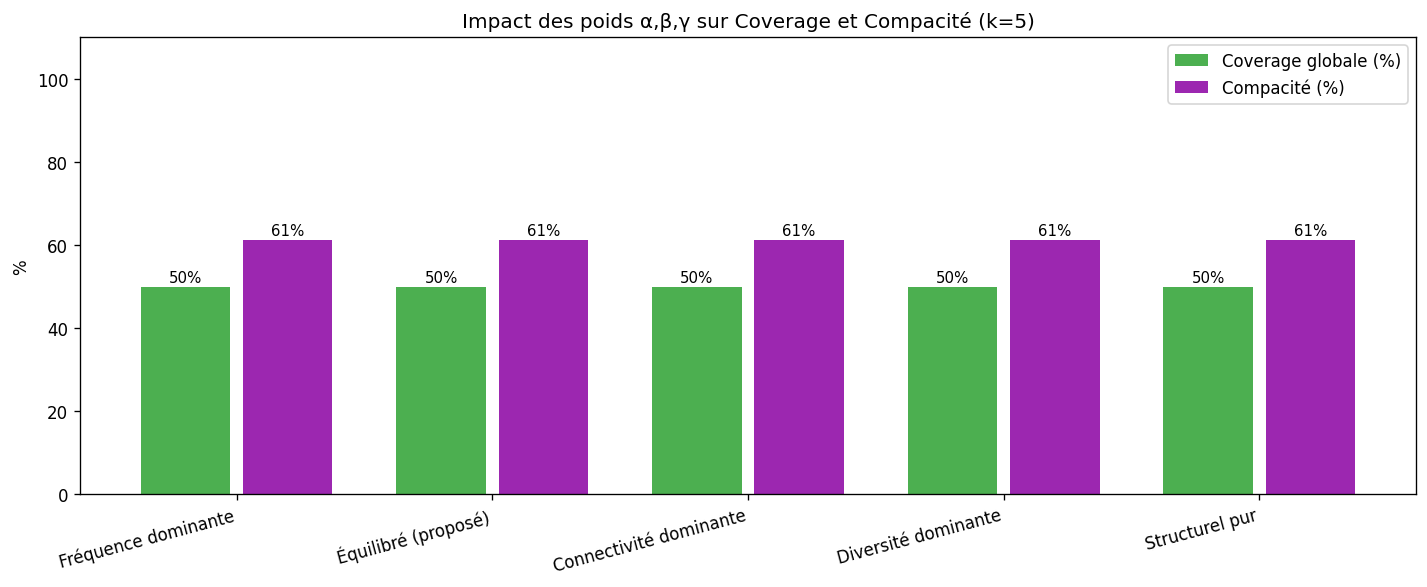


Configuration                   Coverage   Compacité
----------------------------------------------------
Fréquence dominante                50.0%       61.3%
Équilibré (proposé)                50.0%       61.3%
Connectivité dominante             50.0%       61.3%
Diversité dominante                50.0%       61.3%
Structurel pur                     50.0%       61.3%


In [12]:
configs = [
    ("Fréquence dominante",    0.8, 0.1, 0.1),
    ("Équilibré (proposé)",    0.5, 0.3, 0.2),
    ("Connectivité dominante", 0.2, 0.7, 0.1),
    ("Diversité dominante",    0.2, 0.1, 0.7),
    ("Structurel pur",         0.1, 0.5, 0.4),
]

results = []
for label, a, b, g in configs:
    r = compute_importance_scores(subgraphs, schema, total_queries, a, b, g)
    sel  = select_top_k(r, K)
    summ = connect_subgraphs(sel, schema)
    m    = compute_coverage(summ, subgraphs)
    comp = compute_compactness(summ, schema)
    results.append((label, m['coverage_global'] * 100, comp * 100))

labels_cfg = [r[0] for r in results]
covs_cfg   = [r[1] for r in results]
comps_cfg  = [r[2] for r in results]

x = np.arange(len(configs))
fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - 0.2, covs_cfg,  0.35, label='Coverage globale (%)', color='#4CAF50')
bars2 = ax.bar(x + 0.2, comps_cfg, 0.35, label='Compacité (%)',         color='#9C27B0')
ax.set_xticks(x)
ax.set_xticklabels(labels_cfg, rotation=15, ha='right')
ax.set_ylabel('%')
ax.set_title(f'Impact des poids α,β,γ sur Coverage et Compacité (k={K})')
ax.legend()
ax.set_ylim(0, 110)
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.0f}%', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("output/impact_poids.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'Configuration':<28}  {'Coverage':>10}  {'Compacité':>10}")
print("-" * 52)
for label, cov, comp in results:
    print(f"{label:<28}  {cov:>9.1f}%  {comp:>9.1f}%")

## 10. Récapitulatif final

In [13]:
print("=" * 60)
print("   RÉSUMÉ FINAL DE L'EXPÉRIMENTATION")
print("=" * 60)
print()
print(f"Dataset          : SWDF (Semantic Web Dog Food)")
print(f"Ontologie source : SWC 2009-05-11 (lov.linkeddata.es)")
print(f"Logs source      : LSQ / data.semanticweb.org (Mai 2014)")
print()
print(f"Schéma RDF       : {len(schema.classes())} classes, {len(schema.properties())} propriétés")
print(f"Requêtes SPARQL  : {len(queries)} requêtes (dont 3 réelles LSQ)")
print(f"Motifs distincts : {len(subgraphs)} sous-graphes S_q")
print()
print(f"Paramètres       : α={ALPHA}, β={BETA}, γ={GAMMA}, k={K}")
print()
print(f"Résumé produit   : {summary.number_of_nodes()} nœuds, {summary.number_of_edges()} arêtes")
print()
m = compute_coverage(summary, subgraphs)
c = compute_compactness(summary, schema)
print(f"Coverage nœuds   : {m['coverage_nodes']*100:.1f}% ({m['n_covered_nodes']}/{m['n_query_nodes']})")
print(f"Coverage arêtes  : {m['coverage_edges']*100:.1f}% ({m['n_covered_edges']}/{m['n_query_edges']})")
print(f"Coverage globale : {m['coverage_global']*100:.1f}%")
print(f"Compacité        : {c*100:.1f}%")
print()
print("Images générées dans output/ :")
for f in sorted(os.listdir("output")):
    print(f"  - {f}")
print("=" * 60)

   RÉSUMÉ FINAL DE L'EXPÉRIMENTATION

Dataset          : SWDF (Semantic Web Dog Food)
Ontologie source : SWC 2009-05-11 (lov.linkeddata.es)
Logs source      : LSQ / data.semanticweb.org (Mai 2014)

Schéma RDF       : 18 classes, 13 propriétés
Requêtes SPARQL  : 15 requêtes (dont 3 réelles LSQ)
Motifs distincts : 14 sous-graphes S_q

Paramètres       : α=0.5, β=0.3, γ=0.2, k=5

Résumé produit   : 7 nœuds, 5 arêtes

Coverage nœuds   : 58.3% (7/12)
Coverage arêtes  : 37.5% (3/8)
Coverage globale : 50.0%
Compacité        : 61.3%

Images générées dans output/ :
  - coverage_vs_k.png
  - impact_poids.png
  - schema_complet.png
  - schema_full.png
  - schema_vs_resume.png
  - schema_vs_summary.png
  - scores_importance.png
  - summary.png
